In [ ]:
!pip install wandb
!pip install torch_geometric

In [20]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score
from copy import deepcopy
import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import GCNConv, GATv2Conv, GINConv, ChebConv, EdgeConv, global_mean_pool, global_max_pool, global_add_pool
from torch.nn import Sequential, Linear, BatchNorm1d, ReLU
from torch_geometric.nn.inits import glorot, zeros
from collections import OrderedDict
from torch_geometric.utils import to_networkx
from torch_geometric.loader import DataLoader
import networkx as nx
import matplotlib.pyplot as plt

In [21]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [22]:
# Loading the Protein Dataset

from torch_geometric.datasets import TUDataset

dataset = TUDataset(root='.', name='PROTEINS').shuffle()

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')
print('-------------------')
# Nodes of nodes of a random graph
print(f'Number of nodes: {dataset[0].x.shape[0]}')

Dataset: PROTEINS(1113)
-------------------
Number of graphs: 1113
Number of features: 3
Number of classes: 2
-------------------
Number of nodes: 23


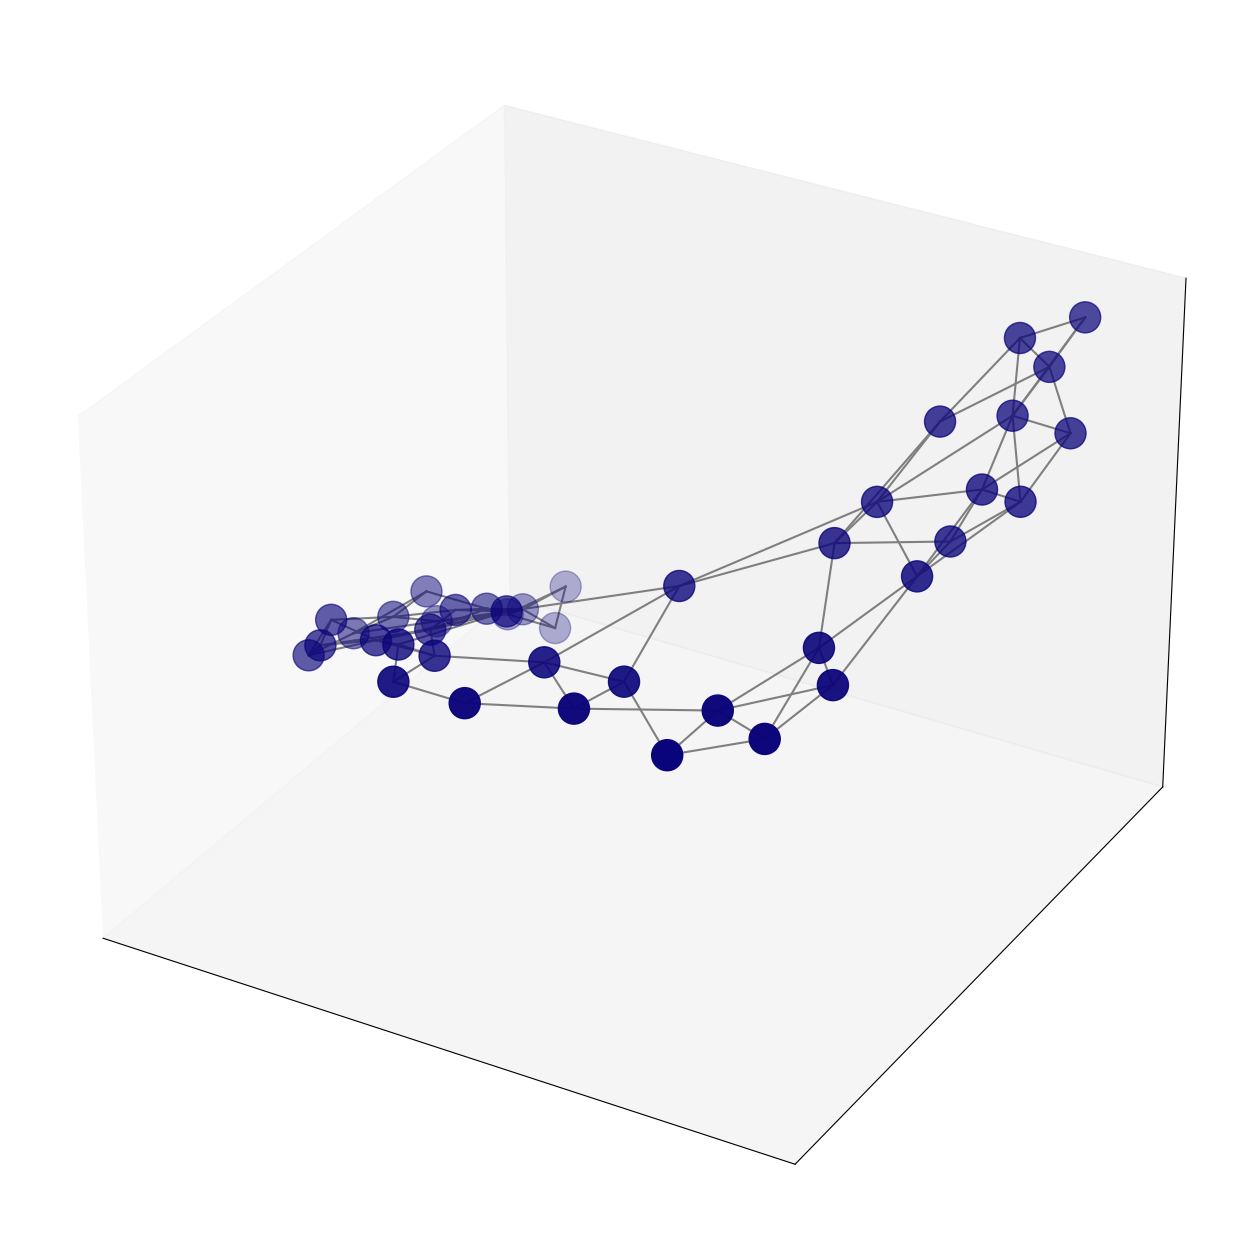

In [23]:
# Visualising one of the proteins

G = to_networkx(dataset[2], to_undirected=True)

# 3D spring layout
pos = nx.spring_layout(G, dim=3, seed=0)

# Extract node and edge positions from the layout
node_xyz = np.array([pos[v] for v in sorted(G)])
edge_xyz = np.array([(pos[u], pos[v]) for u, v in G.edges()])

# Create the 3D figure
fig = plt.figure(figsize=(16,16))
ax = fig.add_subplot(111, projection="3d")

# Suppress tick labels
for dim in (ax.xaxis, ax.yaxis, ax.zaxis):
    dim.set_ticks([])

# Plot the nodes - alpha is scaled by "depth" automatically
ax.scatter(*node_xyz.T, s=500, c="#0A047A")

# Plot the edges
for vizedge in edge_xyz:
    ax.plot(*vizedge.T, color="tab:gray")

# fig.tight_layout()
plt.show()

In [54]:
dataset[2]

Data(edge_index=[2, 184], x=[41, 3], y=[1])

In [51]:
dataset[2].edge_index

tensor([[ 0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  3,
          3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,
          6,  7,  7,  7,  7,  8,  8,  8,  9,  9,  9,  9, 10, 10, 10, 10, 11, 11,
         11, 11, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15,
         15, 15, 15, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 19,
         19, 19, 19, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 23, 23,
         23, 24, 24, 24, 24, 24, 25, 25, 25, 25, 25, 25, 25, 26, 26, 26, 26, 27,
         27, 27, 27, 28, 28, 28, 28, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 33, 33, 33, 33, 34, 34, 34, 34, 34, 35, 35, 35, 35,
         35, 36, 36, 36, 36, 37, 37, 37, 37, 37, 37, 38, 38, 38, 38, 38, 39, 39,
         39, 40, 40, 40],
        [ 1,  4,  5, 14,  0,  4,  5, 10, 12, 25,  3,  5,  6, 15, 16,  2,  6,  7,
         17, 21, 37,  0,  1,  5, 24, 29,  0,  1,  2,  4, 25, 28,  2,  3,  7, 33,
  

In [49]:
dataset[2].y

tensor([1])

In [ ]:
# Next we split the dataset into training, test, and validation sets. We then initialise the data loaders

train_dataset = dataset[:int(len(dataset)*0.8)]
val_dataset   = dataset[int(len(dataset)*0.8):int(len(dataset)*0.9)]
test_dataset  = dataset[int(len(dataset)*0.9):]

In [24]:
# Defining train, validation, and test sets data loaders

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
    )
val_loader = DataLoader(
    val_dataset, 
    batch_size=64, 
    shuffle=True
    )
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False
    )

In [25]:
p=0
for i in train_loader:
    print(i)
    p = p+1

    if p > 2:
        break

DataBatch(edge_index=[2, 8864], x=[2345, 3], y=[64], batch=[2345], ptr=[65])
DataBatch(edge_index=[2, 10400], x=[2834, 3], y=[64], batch=[2834], ptr=[65])
DataBatch(edge_index=[2, 7554], x=[2052, 3], y=[64], batch=[2052], ptr=[65])


In [ ]:
# Defining loss function and readout function

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self):
        super(LabelSmoothingCrossEntropy, self).__init__()
    def forward(self, x, target, smoothing=0.1):
        confidence = 1. - smoothing
        logprobs = F.log_softmax(x, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = confidence * nll_loss + smoothing * smooth_loss
        return loss.mean()


def graph_readout(x, method, batch):
    if method == 'mean':
        return global_mean_pool(x,batch)

    elif method == 'meanmax':
        x_mean = global_mean_pool(x,batch)
        x_max = global_max_pool(x,batch)
        return torch.cat((x_mean, x_max), dim=1)

    elif method == 'sum':
        return global_add_pool(x,batch)

    else:
        raise ValueError('Undefined readout opertaion')

In [ ]:
# Define GNN models architectures

class Abstract_GNN(torch.nn.Module):
    """
    An Abstract class for all GNN models
    Subclasses should implement the following:
    - forward()
    - predict()
    """
    def __init__(self, num_nodes, f1, f2, readout):
        super(Abstract_GNN, self).__init__()
        self.readout = readout

    def _reset_parameters(self):
            for p in self.parameters():
                if p.dim() > 1:
                    nn.init.xavier_uniform_(p)
                else:
                    nn.init.uniform_(p)

    def forward(self, data, edge_index, batch):

        raise NotImplementedError


class GCN(Abstract_GNN):
    def __init__(self, num_nodes, f1, f2, readout, **kwargs):
        super().__init__(num_nodes, f1, f2, readout)
        self.readout = readout
        self.conv1 = GCNConv(num_nodes, f1)
        self.conv2 = GCNConv(f1, f2)

        last_dim = 2 if readout=='meanmax' else 1
        self.mlp = nn.Linear(f2*last_dim, f2)
        self._reset_parameters()


    def forward(self, data, edge_index, batch):
        x = data
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        x = graph_readout(x, self.readout, batch)
        x = self.mlp(x)
        return x



class GIN(Abstract_GNN):
    def __init__(self, num_nodes, f1, f2, readout, **kwargs):
        super().__init__(num_nodes, f1, f2, readout)
        self.conv1 = GINConv(
            Sequential(Linear(num_nodes, f1), BatchNorm1d(f1), ReLU(),
                       Linear(f1, f1), ReLU()))

        self.conv2 = GINConv(
            Sequential(Linear(f1, f1), BatchNorm1d(f1), ReLU(),
                       Linear(f1, f1), ReLU()))
        
        self.conv3 = GINConv(
            Sequential(Linear(f1, f2), BatchNorm1d(f2), ReLU(),
                       Linear(f2, f2), ReLU()))

        last_dim = 2 if readout=='meanmax' else 1

        self.last = Linear(f2*last_dim, f2)

        self._reset_parameters()

    def forward(self, data, edge_index, batch):
        x = data
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = graph_readout(x, self.readout, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.last(x)
        return x


class GAT(Abstract_GNN):
    def __init__(self, num_nodes, f1, f2, readout, concat, num_heads, **kwargs):
        super().__init__(num_nodes, f1, f2, readout)

        self.conv1 = GATv2Conv(num_nodes, f1, heads=num_heads, concat=concat)
        m = num_heads if concat else 1
        self.conv2 = GATv2Conv(f1*m, f2, heads=1)
        last_dim = 2 if readout=='meanmax' else 1
        self.mlp = nn.Linear(f2*last_dim, f2)
        self._reset_parameters()


    def forward(self, data, edge_index, batch):
        x = data
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        x = graph_readout(x, self.readout, batch)
        x = self.mlp(x)
        return x

class ChebC(Abstract_GNN):
    def __init__(self, num_nodes, f1, f2, k, readout):
        super().__init__(num_nodes, f1, f2, readout)
        self.conv1 = ChebConv(num_nodes, f1, k)
        self.conv2 = ChebConv(f1, f1, k)
        self.conv3 = ChebConv(f1, f1, k)
        self.readout = readout
        last_dim = 2 if readout == 'meanmax' else 1
        self.fc = nn.Linear(f1 * last_dim, f2)
    
    def forward(self, data, edge_index, batch):
        x = data
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = graph_readout(x, self.readout, batch)
        x = self.fc(x)
        return x

class ChebEdge(Abstract_GNN):
    def __init__(self, num_nodes, f1, f2, k, readout):
        super().__init__(num_nodes, f1, f2, readout)
        self.conv1 = ChebConv(num_nodes, f1, k)
        self.conv2 = ChebConv(f1, f1, k)
        self.conv3 = ChebConv(f1, f1, k)
        
        self.edgeconv1 = EdgeConv(nn.Sequential(nn.Linear(f1*2, f1*2), nn.ReLU(), nn.Linear(f1*2, f1)))
        self.edgeconv2 = EdgeConv(nn.Sequential(nn.Linear(f1*2, f1*2), nn.ReLU(), nn.Linear(f1*2, f1)))
        
        last_dim = 2 if readout == 'meanmax' else 1
        self.fc = nn.Linear(f1 * last_dim, f2)
        
    def forward(self, data, edge_index, batch):
        x = data
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.edgeconv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.edgeconv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = graph_readout(x, self.readout, batch)
        x = self.fc(x)
        return x

In [ ]:
# Defining training, validation, and test functions

def train(model, train_loader, val_loader, device):

    model = model.to(device)

    loss_function = LabelSmoothingCrossEntropy()
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-5)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = 400, eta_min = 1e-5)

    # start a typical PyTorch training
    best_metric = -1
    best_metric_epoch = -1
    best_val_loss = 1000
    best_model = None
    epochs = 500

    print('-'*30)
    print ('Training ... ')
    early_stop = 30
    es_counter = 0

    for epoch in range(epochs):

        print("-" * 10)
        print(f"epoch {epoch + 1}/{epochs}")
        model.train()
        epoch_train_loss = 0

        for i, data in enumerate(tqdm(train_loader)):
            batch = data.batch.to(device)
            x = data.x.to(device)
            y = data.y.to(device)
            z = data.edge_index.to(device)
            optimizer.zero_grad()

            out = model(x,z,batch)

            step_loss = loss_function(out, y)
            step_loss.backward(retain_graph=True)
            optimizer.step()
            epoch_train_loss += step_loss.item()

        epoch_train_loss = epoch_train_loss/(i+1)
        lr_scheduler.step()
        val_loss, val_acc = validate_model(model, val_loader, device)
        print(f"epoch {epoch + 1} train loss: {epoch_train_loss:.4f}")

        if val_loss < best_val_loss:
            best_metric = val_acc
            best_val_loss = val_loss
            best_metric_epoch = epoch + 1
            best_model = deepcopy(model)
            print("saved new best metric model")
            es_counter = 0
        else:
            es_counter += 1

        if es_counter > early_stop:
            print('No loss improvment.')
            break

        wandb_metric = {'train_loss':epoch_train_loss, 'val_loss':val_loss, 'val_acc': val_acc, 'best_val_loss': best_val_loss }
        wandb.log(wandb_metric)

        print(
            "current epoch: {} current val loss {:.4f} current accuracy: {:.4f}  best accuracy: {:.4f} at loss {:.4f} at epoch {}".format(
                epoch + 1, val_loss, val_acc, best_metric, best_val_loss, best_metric_epoch))


    print(f"train completed, best_val_loss: {best_val_loss:.4f} at epoch: {best_metric_epoch}")

    return best_model


def validate_model(model, val_loader, device):
    model.eval()
    val_loss = 0
    loss_func = nn.CrossEntropyLoss()

    labels = []
    preds = []
    for i, data in enumerate(val_loader):
            batch = data.batch.to(device)
            x = data.x.to(device)
            label = data.y.to(device)
            z = data.edge_index.to(device)

            out = model(x,z,batch)

            step_loss = loss_func(out, label)
            val_loss += step_loss.detach().item()
            preds.append(out.argmax(dim=1).detach().cpu().numpy())
            labels.append(label.cpu().numpy())
    preds = np.concatenate(preds).ravel()
    labels =  np.concatenate(labels).ravel()
    acc = balanced_accuracy_score(preds, labels)
    loss = val_loss/(i+1)

    return loss, acc

def test_model(model, test_loader, device):
    model.eval()
    labels = []
    preds = []
    for i, data in enumerate(test_loader):
            batch = data.batch.to(device)
            x = data.x.to(device)
            label = data.y.to(device)
            z = data.edge_index.to(device)

            out = model(x,z,batch)
            preds.append(out.argmax(dim=1).detach().cpu().numpy())
            labels.append(label.cpu().numpy())
    preds = np.concatenate(preds).ravel()
    labels =  np.concatenate(labels).ravel()
    
    accuracy = balanced_accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return accuracy, precision, recall, f1

In [ ]:
# Initialise logging

wandb.init(project="gb")

In [ ]:
# Initialise and train GCN Model

GCN_ = GCN(dataset.num_node_features, 32, dataset.num_classes, readout='meanmax')
gcnModel = train(GCN_, train_loader, val_loader, device)

In [ ]:
# Initialise and train GIN Model

GIN_ = GIN(dataset.num_node_features, 32, dataset.num_classes, readout='mean')
ginModel = train(GIN_, train_loader, val_loader, device)

In [ ]:
# Initialise and train GAT Model

GAT_ = GAT(dataset.num_node_features, 32, dataset.num_classes, readout='sum', concat=True, num_heads=8)
gatModel = train(GAT_, train_loader, val_loader, device)

In [ ]:
# Initialise and train Chebnet Model

chebFilterSize = 16

ChebC_ = ChebC(dataset.num_node_features, 32, dataset.num_classes, chebFilterSize, readout='meanmax')
chebModel = train(ChebC_, train_loader, val_loader, device)

In [ ]:
# Initialise and train Chebnet + EdgeConv Model

chebFilterSize = 16

ChebEdge_ = ChebEdge(dataset.num_node_features, 32, dataset.num_classes, chebFilterSize, readout='meanmax')
chbedgModel = train(ChebEdge_, train_loader, val_loader, device)

In [19]:
# Evaluate each model on the test dataset and store the results
gcn_accuracy, gcn_precision, gcn_recall, gcn_f1 = test_model(gcnModel, test_loader, device)
gin_accuracy, gin_precision, gin_recall, gin_f1 = test_model(ginModel, test_loader, device)
gat_accuracy, gat_precision, gat_recall, gat_f1 = test_model(gatModel, test_loader, device)
cheb_accuracy, cheb_precision, cheb_recall, cheb_f1 = test_model(chebModel, test_loader, device)
cheb_edge_accuracy, cheb_edge_precision, cheb_edge_recall, cheb_edge_f1 = test_model(chbedgModel, test_loader, device)

# Create a DataFrame to store the results
data = {
    "Model Name": ["GCN", "GIN", "GAT", "Chebnet", "Chebnet + EdgeConv"],
    "Balanced Accuracy": [gcn_accuracy, gin_accuracy, gat_accuracy, cheb_accuracy, cheb_edge_accuracy],
    "Precision": [gcn_precision, gin_precision, gat_precision, cheb_precision, cheb_edge_precision],
    "Recall": [gcn_recall, gin_recall, gat_recall, cheb_recall, cheb_edge_recall],
    "F1-score": [gcn_f1, gin_f1, gat_f1, cheb_f1, cheb_edge_f1]
}

df = pd.DataFrame(data)

print(df)

     Model Name  Balanced Accuracy  Precision    Recall  F1-score
0           GCN           0.743175   0.618182  0.790698  0.693878
1           GIN           0.594708   0.576923  0.348837  0.434783
2           GAT           0.698180   0.571429  0.744186  0.646465
3      ChebConv           0.754634   0.697674  0.697674  0.697674
4  ChebEdgeConv           0.699360   0.685714  0.558140  0.615385
